In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import PROCESSED_DATA, CHURN_RECENCY

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load Cleaned Data

In [2]:
df = pd.read_csv(PROCESSED_DATA, encoding="ISO-8859-1")

In [4]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
df.shape

(797815, 10)

## RFM Feature Engineering
Compute Recency, Frequency, and Monetary value per customer, excluding cancelled orders
from Frequency and Monetary (a cancellation isn't purchasing activity).

In [12]:
# Most recent invoice date in the dataset (day after, to avoid recency of 0)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

## Exclude cancellations for Frequency/Monetary
non_cancelled = df[df["is_cancelled"] == False]

rfm = non_cancelled.groupby("CustomerID").agg(
    last_purchase_date=("InvoiceDate", "max"),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum")
).reset_index()

rfm["recency_days"] = (reference_date - rfm["last_purchase_date"]).dt.days

rfm = rfm[["CustomerID", "recency_days", "frequency", "monetary"]]
rfm.head()

Reference Date: 2011-12-10 12:50:00


,CustomerID,recency_days,frequency,monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


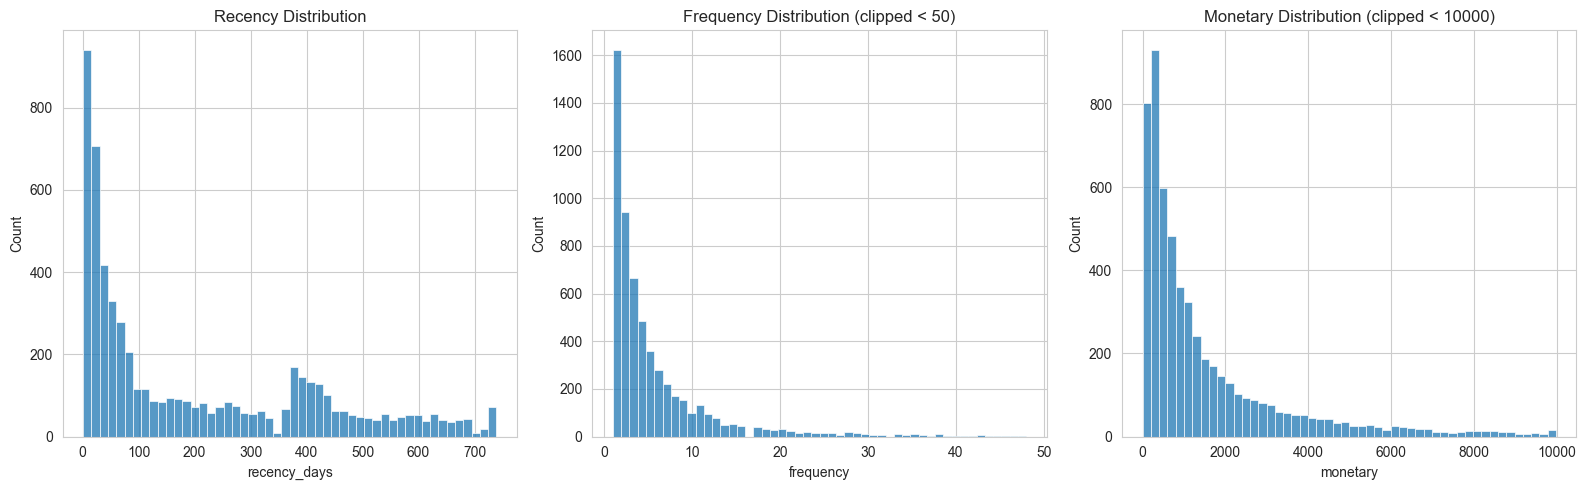

       recency_days    frequency       monetary
count   5878.000000  5878.000000    5878.000000
mean     201.331916     6.289384    2955.904095
std      209.338707    13.009406   14440.852688
min        1.000000     1.000000       2.950000
25%       26.000000     1.000000     342.280000
50%       96.000000     3.000000     867.740000
75%      380.000000     7.000000    2248.305000
max      739.000000   398.000000  580987.040000


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.histplot(rfm["recency_days"], bins=50, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm[rfm["frequency"] < 50]["frequency"], bins=50, ax=axes[1])
axes[1].set_title("Frequency Distribution (clipped < 50)")

sns.histplot(rfm[rfm["monetary"] < 10000]["monetary"], bins=50, ax=axes[2])
axes[2].set_title("Monetary Distribution (clipped < 10000)")

plt.tight_layout()
plt.show() 

print(rfm[["recency_days", "frequency", "monetary"]].describe())

## Churn Label
A customer is labeled churned if they haven't purchased in more than 90 days
(threshold chosen based on EDA — close to median recency observed in the dataset).

In [17]:
rfm["is_churned"] = (rfm["recency_days"] > CHURN_RECENCY).astype(int)

churn_rate = rfm["is_churned"].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")
rfm["is_churned"].value_counts()

Churn rate: 50.85%


is_churned
1    2989
0    2889
Name: count, dtype: int64

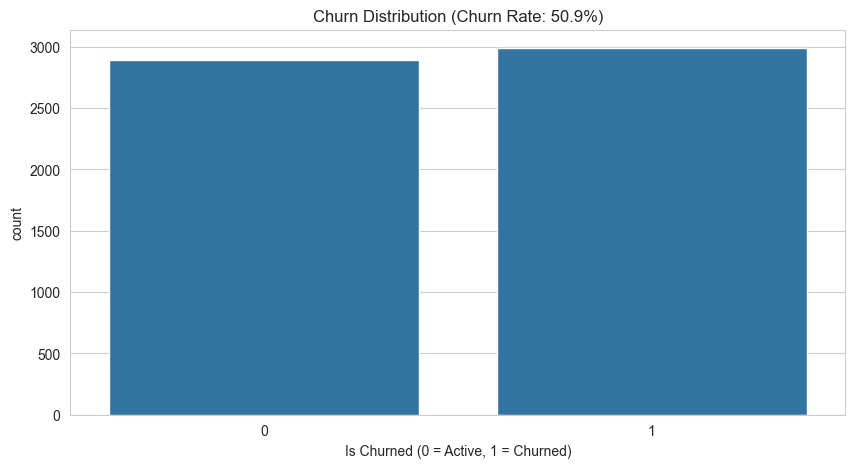

In [18]:
plt.figure()
sns.countplot(x="is_churned", data=rfm)
plt.title(f"Churn Distribution (Churn Rate: {churn_rate:.1f}%)")
plt.xlabel("Is Churned (0 = Active, 1 = Churned)")
plt.show()

In [19]:
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

# Quantile-based RFM scores (1-4, 4 = best) — classic RFM segmentation technique
rfm["R_score"] = pd.qcut(rfm["recency_days"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()

,CustomerID,recency_days,frequency,monetary,is_churned,avg_order_value,R_score,F_score,M_score,RFM_score
0,12346,326,12,77556.46,1,6463.038333,2,4,4,10
1,12347,2,8,4921.53,0,615.191250,4,4,4,12
2,12348,75,5,2019.40,0,403.880000,3,3,3,9
3,12349,19,4,4428.69,0,1107.172500,4,3,4,11
4,12350,310,1,334.40,1,334.400000,2,1,1,4


In [20]:
def segment_customer(score):
    if score >= 10:
        return "Champion"
    elif score >= 8:
        return "Loyal"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost"

rfm["segment"] = rfm["RFM_score"].apply(segment_customer)
rfm["segment"].value_counts()

segment
Champion    1740
Lost        1736
At Risk     1216
Loyal       1186
Name: count, dtype: int64

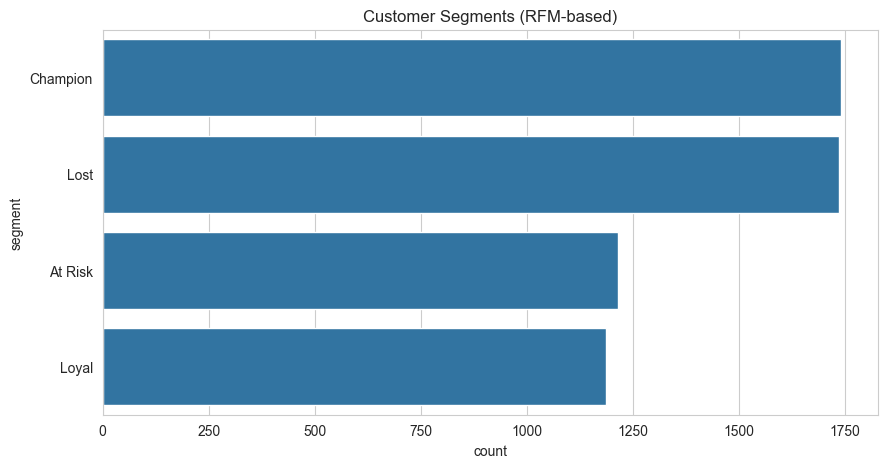

In [21]:
plt.figure()
sns.countplot(y="segment", data=rfm, order=rfm["segment"].value_counts().index)
plt.title("Customer Segments (RFM-based)")
plt.show()

In [22]:
customer_country = df.groupby("CustomerID")["Country"].agg(lambda x: x.mode()[0]).reset_index()
rfm = rfm.merge(customer_country, on="CustomerID", how="left")
rfm.head()

,CustomerID,recency_days,frequency,monetary,is_churned,avg_order_value,R_score,F_score,M_score,RFM_score,segment,Country
0,12346,326,12,77556.46,1,6463.038333,2,4,4,10,Champion,United Kingdom
1,12347,2,8,4921.53,0,615.191250,4,4,4,12,Champion,Iceland
2,12348,75,5,2019.40,0,403.880000,3,3,3,9,Loyal,Finland
3,12349,19,4,4428.69,0,1107.172500,4,3,4,11,Champion,Italy
4,12350,310,1,334.40,1,334.400000,2,1,1,4,Lost,Norway


In [23]:
import os
output_path = os.path.join(os.path.dirname(PROCESSED_DATA), "customer_features.csv")
rfm.to_csv(output_path, index=False)
print(f"Saved feature-engineered customer data to: {output_path}")
print(rfm.shape)

Saved feature-engineered customer data to: C:\Users\GAUTAM MISHRA\retail-churn-intelligence\data\processed\customer_features.csv
(5878, 12)


## Feature Engineering Summary

- RFM computed for **5,878** unique customers
- Churn rate at 90-day threshold: **50.85%** (2,989 churned, 2,889 active) — a well-balanced split, meaning SMOTE/class-weighting likely won't be necessary at modeling time
- Customer segments: **1,740** Champions, **1,186** Loyal, **1,216** At Risk, **1,736** Lost
- Recency ranges from 1 to 739 days (mean ~201, median 96) — consistent with the EDA findings
- Frequency is right-skewed: median of 3 orders, but a max of 398 — a small number of highly active bulk/wholesale customers pull the average up
- Monetary value is also heavily right-skewed: median spend of ~£868 vs. a max of ~£581,000 — a few very high-value customers dominate total revenue, reinforcing the value of RFM-based segmentation over treating all customers equally
- Final feature set: `recency_days`, `frequency`, `monetary`, `avg_order_value`, `R_score`, `F_score`, `M_score`, `RFM_score`, `segment`, `is_churned`, `Country`
- Saved as `customer_features.csv` (5,878 rows × 12 columns) — this is the direct input to the modeling notebook (Step 13)